# temporal predictions 

Minimal notebook setup for exploring predictive coding with NumPy, PyTorch, and torchvision.

In [53]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.datasets as datasets
import torchvision.transforms as transforms
import torch.nn.functional as F
import math
import os as os

In [54]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"PyTorch: {torch.__version__}")
print(f"NumPy: {np.__version__}")

Using device: cpu
PyTorch: 2.13.0
NumPy: 2.5.2


dataset/input variables

In [55]:
if not os.path.exists("./data/MovingMNIST/mnist_test_seq.npy"):
    datasets.MovingMNIST._URL = "https://huggingface.co/datasets/goodgoodideas/STDN/resolve/main/mnist_test_seq.npy"
input_data = datasets.MovingMNIST(root="./data", split=None, download=True)

In [56]:
def make_variables(image, initial_r_size=64, num_channels=16, num_layers=2, kernel_size=4, padding=1, stride=2):
    I = image
    if I.ndim == 4:
        previous_num_channels = I.shape[1]
    elif I.ndim == 3:
        previous_num_channels = I.shape[0]
    else:
        previous_num_channels = 1
    r = []
    deconvs = []
    out_channels = num_channels * 2
    for i in range(num_layers):
        r_size = initial_r_size // (2 ** (i + 1))
        r.append(torch.randn(1, out_channels, r_size, r_size) * 0.01)
        deconvs.append(nn.ConvTranspose2d(out_channels, previous_num_channels, kernel_size=kernel_size, padding=padding, stride=stride, bias=False))
        previous_num_channels = out_channels
        out_channels = out_channels * 2
    return I, r, deconvs

spatial pretrain


In [57]:
def pretrain_spatial(frames, r_init, alpha, lambda_u, lr_r, lr_u, sigma_2, num_epochs, num_epochs_inner, num_layers, deconvs):
    print("Starting Spatial Pre-training...")
    f = lambda x: torch.clamp(x, min=-1.0, max=1.0)

    for epoch in range(num_epochs):
        for I in frames:
            I_curr = I.float()
            if I_curr.ndim == 3:
                I_curr = I_curr.unsqueeze(0)
            I_curr = I_curr - I_curr.mean()

            r_curr = [ri.clone() for ri in r_init]
            e_spatial = [None] * num_layers

            for _ in range(num_epochs_inner):
                e_spatial[0] = I_curr - f(deconvs[0](r_curr[0]))
                for i in range(1, num_layers):
                    e_spatial[i] = r_curr[i - 1] - f(deconvs[i](r_curr[i]))

                for i in range(num_layers):
                    cauchy_prior = alpha * (2 * r_curr[i] / (1 + r_curr[i] ** 2))
                    bottom_up = F.conv2d(e_spatial[i], deconvs[i].weight, padding=deconvs[i].padding, stride=deconvs[i].stride)
                    dr = (1.0 / sigma_2) * bottom_up - cauchy_prior
                    if i < num_layers - 1:
                        dr = dr - (1.0 / sigma_2) * e_spatial[i + 1]
                    r_curr[i] = (r_curr[i] + lr_r * dr).detach()
                    r_curr[i].requires_grad = True

            for j in range(num_layers):
                if j > 0:
                    e_spatial[j] = r_curr[j - 1] - f(deconvs[j](r_curr[j]))
                else:
                    e_spatial[0] = I_curr - f(deconvs[0](r_curr[0]))

                loss = (1.0 / (2 * sigma_2)) * torch.sum(e_spatial[j]**2)
                deconvs[j].zero_grad()
                loss.backward()

                with torch.no_grad():
                    if deconvs[j].weight.grad is not None:
                        deconvs[j].weight -= lr_u * (deconvs[j].weight.grad + lambda_u * deconvs[j].weight)
                        deconvs[j].weight /= (torch.linalg.vector_norm(deconvs[j].weight, ord=2, dim=(1, 2, 3), keepdim=True) + 1e-8)
                        deconvs[j].weight.grad = None

        I_vis = frames[0].float()
        if I_vis.ndim == 3:
            I_vis = I_vis.unsqueeze(0)
        I_vis = I_vis - I_vis.mean()
        r_vis = [ri.clone() for ri in r_init]
        e_spatial = [None] * num_layers
        for _ in range(num_epochs_inner):
            e_spatial[0] = I_vis - f(deconvs[0](r_vis[0]))
            for i in range(1, num_layers):
                e_spatial[i] = r_vis[i - 1] - f(deconvs[i](r_vis[i]))
            for i in range(num_layers):
                cauchy_prior = alpha * (2 * r_vis[i] / (1 + r_vis[i] ** 2))
                bottom_up = F.conv2d(e_spatial[i], deconvs[i].weight, padding=deconvs[i].padding, stride=deconvs[i].stride)
                dr = (1.0 / sigma_2) * bottom_up - cauchy_prior
                if i < num_layers - 1:
                    dr = dr - (1.0 / sigma_2) * e_spatial[i + 1]
                r_vis[i] = (r_vis[i] + lr_r * dr).detach()
        with torch.no_grad():
            I_hat = f(deconvs[0](r_vis[0]))
            mse = torch.mean((I_vis - I_hat) ** 2).item()
        print(f"[Spatial Epoch {epoch:03d}]  Recon MSE: {mse:.6f}")
        fig, axes = plt.subplots(1, 2, figsize=(6, 3))
        axes[0].imshow(I_vis.reshape(64, 64).detach().numpy(), cmap="gray", vmin=-0.5, vmax=0.5)
        axes[0].set_title("Original")
        axes[0].axis("off")
        axes[1].imshow(I_hat.reshape(64, 64).detach().numpy(), cmap="gray", vmin=-0.5, vmax=0.5)
        axes[1].set_title("Reconstruction")
        axes[1].axis("off")
        plt.show()

    return deconvs


## Latent smoothness / inference diagnostics (do this first)

**A.** Same frame, two random inits → if `cos` is low (~0.5), chaos is inference non-convergence.
**B.** Consecutive vs unrelated grounded `r`s (cold-start vs warm-start from `r_prev`).
Fixes if A fails: more inner iters, warm-start, higher `lr_r`, convergence check.


Starting Spatial Pre-training...
[Spatial Epoch 000]  Recon MSE: 0.000855


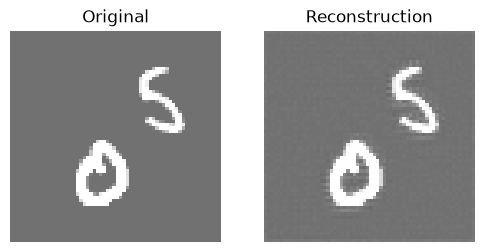

[Spatial Epoch 001]  Recon MSE: 0.000657


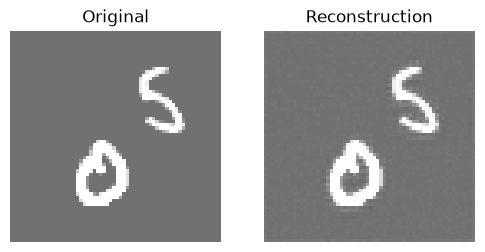

[Spatial Epoch 002]  Recon MSE: 0.000568


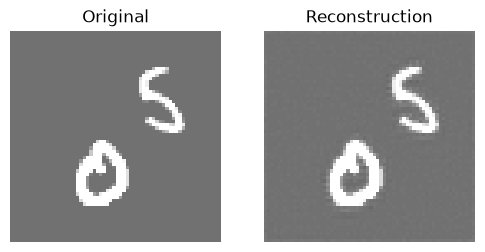

[Spatial Epoch 003]  Recon MSE: 0.000515


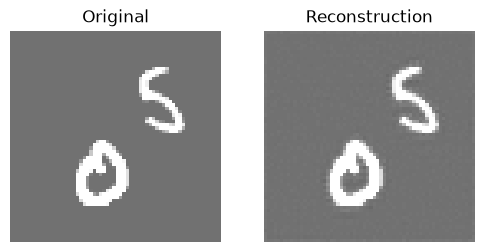

[Spatial Epoch 004]  Recon MSE: 0.000479


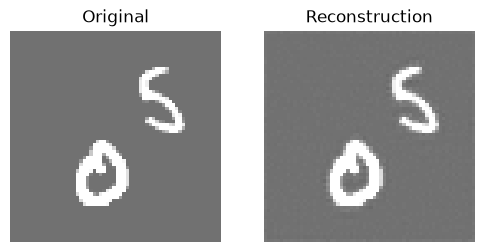

[Spatial Epoch 005]  Recon MSE: 0.000453


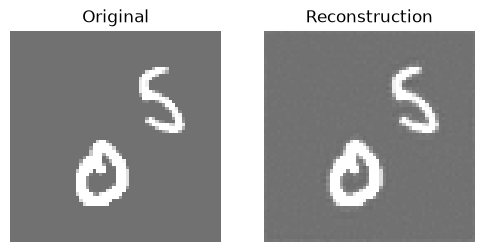


A. Inference non-determinism  (same frame ×2 random inits, inner=50, lr_r=0.005)
  frame 0: cos=0.7312  rel=0.7334  ||dr||=2.4580  iters=50/50
  frame 1: cos=0.7300  rel=0.7354  ||dr||=2.4709  iters=50/50
  frame 2: cos=0.7283  rel=0.7367  ||dr||=2.4625  iters=50/50
  frame 3: cos=0.7299  rel=0.7350  ||dr||=2.4644  iters=50/50
  frame 4: cos=0.7306  rel=0.7337  ||dr||=2.4594  iters=50/50
  MEAN cos=0.7300  rel=0.7349
  VERDICT: settle is fairly deterministic — remaining jumpiness is more about the code.

A. Inference non-determinism  (same frame ×2 random inits, inner=200, lr_r=0.02)
  frame 0: cos=0.9365  rel=0.3566  ||dr||=1.6151  iters=200/200
  frame 1: cos=0.9375  rel=0.3534  ||dr||=1.6088  iters=200/200
  frame 2: cos=0.9346  rel=0.3615  ||dr||=1.6268  iters=200/200
  frame 3: cos=0.9369  rel=0.3552  ||dr||=1.6100  iters=200/200
  frame 4: cos=0.9366  rel=0.3560  ||dr||=1.6077  iters=200/200
  MEAN cos=0.9364  rel=0.3566
  VERDICT: settle is fairly deterministic — remaining jump

In [58]:
def settle_grounded(
    I, r_init, deconvs, alpha, lr_r, sigma_2, num_epochs_inner, num_layers,
    r_warm=None, conv_tol=None, init_noise=0.01,
):
    """Encode one frame with spatial settle only (no temporal prior).

    r_warm: if given, start from these activations (e.g. previous frame).
    Otherwise start from r_init shapes with fresh Gaussian noise (non-determinism test).
    conv_tol: if set, stop early when mean ||dr|| < conv_tol.
    """
    f = lambda x: torch.clamp(x, min=-1.0, max=1.0)
    I_curr = I.float()
    if I_curr.ndim == 3:
        I_curr = I_curr.unsqueeze(0)
    I_curr = I_curr - I_curr.mean()

    if r_warm is not None:
        r_curr = [ri.detach().clone() for ri in r_warm]
    else:
        r_curr = [torch.randn_like(ri) * init_noise for ri in r_init]

    e_spatial = [None] * num_layers
    n_used = num_epochs_inner
    for it in range(num_epochs_inner):
        e_spatial[0] = I_curr - f(deconvs[0](r_curr[0]))
        for i in range(1, num_layers):
            e_spatial[i] = r_curr[i - 1] - f(deconvs[i](r_curr[i]))
        max_step = 0.0
        for i in range(num_layers):
            cauchy_prior = alpha * (2 * r_curr[i] / (1 + r_curr[i] ** 2))
            bottom_up = F.conv2d(
                e_spatial[i], deconvs[i].weight,
                padding=deconvs[i].padding, stride=deconvs[i].stride,
            )
            dr = (1.0 / sigma_2) * bottom_up - cauchy_prior
            if i < num_layers - 1:
                dr = dr - (1.0 / sigma_2) * e_spatial[i + 1]
            r_curr[i] = (r_curr[i] + lr_r * dr).detach()
            max_step = max(max_step, torch.mean(dr.abs()).item())
        if conv_tol is not None and max_step < conv_tol:
            n_used = it + 1
            break
    return [ri.detach().clone() for ri in r_curr], n_used


def _flat_r(r_list):
    return torch.cat([ri.reshape(-1) for ri in r_list])


def _pair_stats(ra, rb):
    a, b = _flat_r(ra), _flat_r(rb)
    cos = F.cosine_similarity(a.unsqueeze(0), b.unsqueeze(0)).item()
    rel = (torch.norm(a - b) / (torch.norm(a) + 1e-8)).item()
    abs_dist = torch.norm(a - b).item()
    return cos, rel, abs_dist


def diagnose_inference_nondeterminism(
    frames, r_init, deconvs,
    alpha=0.001, lr_r=0.005, sigma_2=1.0,
    num_epochs_inner=50, num_layers=2, n_frames=5,
):
    """Settle the same frame twice from different random inits; report cos."""
    print("\n" + "=" * 60)
    print(f"A. Inference non-determinism  (same frame ×2 random inits, inner={num_epochs_inner}, lr_r={lr_r})")
    print("=" * 60)
    cos_list, rel_list = [], []
    for k, I in enumerate(frames[:n_frames]):
        r1, n1 = settle_grounded(I, r_init, deconvs, alpha, lr_r, sigma_2, num_epochs_inner, num_layers)
        r2, n2 = settle_grounded(I, r_init, deconvs, alpha, lr_r, sigma_2, num_epochs_inner, num_layers)
        cos, rel, abs_d = _pair_stats(r1, r2)
        cos_list.append(cos)
        rel_list.append(rel)
        print(f"  frame {k}: cos={cos:.4f}  rel={rel:.4f}  ||dr||={abs_d:.4f}  iters={n1}/{n2}")
    m_cos, m_rel = float(np.mean(cos_list)), float(np.mean(rel_list))
    print(f"  MEAN cos={m_cos:.4f}  rel={m_rel:.4f}")
    if m_cos < 0.7:
        print("  VERDICT: inference does NOT converge to a unique code — 'chaos' is largely settle noise.")
    else:
        print("  VERDICT: settle is fairly deterministic — remaining jumpiness is more about the code.")
    return {"cos": m_cos, "rel": m_rel}


def diagnose_latent_smoothness(
    seq, unrelated_frames, r_init, deconvs,
    alpha=0.001, lr_r=0.005, sigma_2=1.0,
    num_epochs_inner=50, num_layers=2, max_unrelated_pairs=40,
    warm_start=False, label="",
):
    """Grounded trajectory vs unrelated-frame distances in r-space."""
    seq = seq.float()
    if seq.ndim == 3:
        seq = seq.unsqueeze(1)
    T = seq.shape[0]
    tag = label or ("warm-start" if warm_start else "cold-start")

    print("\n" + "=" * 60)
    print(f"B. Latent smoothness [{tag}]  inner={num_epochs_inner}  lr_r={lr_r}")
    print("=" * 60)

    print("Settling grounded trajectory...")
    rs = []
    r_prev = None
    for t in range(T):
        r_t, _ = settle_grounded(
            seq[t], r_init, deconvs, alpha, lr_r, sigma_2, num_epochs_inner, num_layers,
            r_warm=r_prev if warm_start else None,
        )
        rs.append(r_t)
        r_prev = r_t

    cons_cos, cons_rel, cons_abs = [], [], []
    print(f"\n{'t':>4}  {'cos(r_t,r_t-1)':>14}  {'||dr||/||r_t||':>14}  {'||dr||':>10}")
    for t in range(1, T):
        cos, rel, abs_d = _pair_stats(rs[t], rs[t - 1])
        cons_cos.append(cos)
        cons_rel.append(rel)
        cons_abs.append(abs_d)
        print(f"{t:4d}  {cos:14.4f}  {rel:14.4f}  {abs_d:10.4f}")

    print("\nSettling unrelated frames (always cold-start)...")
    u_rs = []
    for I in unrelated_frames:
        r_u, _ = settle_grounded(I, r_init, deconvs, alpha, lr_r, sigma_2, num_epochs_inner, num_layers)
        u_rs.append(r_u)
    un_cos, un_rel, un_abs = [], [], []
    n_u = len(u_rs)
    pairs = [(i, j) for i in range(n_u) for j in range(i + 1, n_u)]
    if len(pairs) > max_unrelated_pairs:
        idx = torch.randperm(len(pairs))[:max_unrelated_pairs].tolist()
        pairs = [pairs[k] for k in idx]
    for i, j in pairs:
        cos, rel, abs_d = _pair_stats(u_rs[i], u_rs[j])
        un_cos.append(cos)
        un_rel.append(rel)
        un_abs.append(abs_d)

    m_cc, m_cr, m_ca = np.mean(cons_cos), np.mean(cons_rel), np.mean(cons_abs)
    m_uc, m_ur, m_ua = np.mean(un_cos), np.mean(un_rel), np.mean(un_abs)
    frac_rel = m_cr / (m_ur + 1e-8)
    frac_abs = m_ca / (m_ua + 1e-8)

    print(f"\nConsecutive ({tag}):  cos={m_cc:.4f}  rel={m_cr:.4f}  ||dr||={m_ca:.4f}")
    print(f"Unrelated frames:      cos={m_uc:.4f}  rel={m_ur:.4f}  ||dr||={m_ua:.4f}")
    print(f"consec/unrelated:      rel={frac_rel:.3f}  abs={frac_abs:.3f}")
    if frac_rel > 0.7:
        print("VERDICT: NON-SMOOTH — consecutive ≈ unrelated.")
    elif frac_rel > 0.4:
        print("VERDICT: moderately jumpy.")
    else:
        print("VERDICT: usable — consecutive clearly closer than unrelated.")
    return {
        "cons_cos": m_cc, "cons_rel": m_cr, "cons_abs": m_ca,
        "un_cos": m_uc, "un_rel": m_ur, "un_abs": m_ua,
        "frac_rel": frac_rel, "frac_abs": frac_abs, "tag": tag,
    }


# --- run diagnostics ---
_diag_num_layers = 2
_diag_alpha, _diag_lr_r, _diag_lr_U = 0.001, 0.005, 0.002
_diag_lambda_u, _diag_sigma_2 = 0.001, 1.0
_diag_spatial_epochs = 6
_diag_pretrain_frames = 120

_diag_seq = input_data[0].float() / 255.0
_diag_unrelated = [
    (input_data[i][t].float() / 255.0)
    for i in range(1, 6)
    for t in (0, 10)
]
_diag_frames = [_diag_seq[t] for t in range(0, min(5, _diag_seq.shape[0]))]

_, _diag_r_init, _diag_deconvs = make_variables(_diag_seq[0], num_layers=_diag_num_layers)
_all = [_diag_seq[t] for t in range(_diag_seq.shape[0])]
_all += [input_data[i][t].float() / 255.0 for i in range(1, 8) for t in range(0, 20, 4)]
_idx = torch.randperm(len(_all))[:_diag_pretrain_frames].tolist()
_diag_deconvs = pretrain_spatial(
    [_all[i] for i in _idx], _diag_r_init,
    _diag_alpha, _diag_lambda_u, _diag_lr_r, _diag_lr_U, _diag_sigma_2,
    _diag_spatial_epochs, 50, _diag_num_layers, _diag_deconvs,
)
for _d in _diag_deconvs:
    _d.weight.requires_grad = False

# A0: baseline non-determinism at 50 iters
_nd50 = diagnose_inference_nondeterminism(
    _diag_frames, _diag_r_init, _diag_deconvs,
    alpha=_diag_alpha, lr_r=_diag_lr_r, sigma_2=_diag_sigma_2,
    num_epochs_inner=50, num_layers=_diag_num_layers,
)

# A1: more iters + higher lr_r
_nd200 = diagnose_inference_nondeterminism(
    _diag_frames, _diag_r_init, _diag_deconvs,
    alpha=_diag_alpha, lr_r=0.02, sigma_2=_diag_sigma_2,
    num_epochs_inner=200, num_layers=_diag_num_layers,
)

# B0: cold-start 50 (previous diagnostic)
_s_cold = diagnose_latent_smoothness(
    _diag_seq, _diag_unrelated, _diag_r_init, _diag_deconvs,
    alpha=_diag_alpha, lr_r=_diag_lr_r, sigma_2=_diag_sigma_2,
    num_epochs_inner=50, num_layers=_diag_num_layers, warm_start=False,
)

# B1: warm-start + more iters + higher lr_r
_s_warm = diagnose_latent_smoothness(
    _diag_seq, _diag_unrelated, _diag_r_init, _diag_deconvs,
    alpha=_diag_alpha, lr_r=0.02, sigma_2=_diag_sigma_2,
    num_epochs_inner=200, num_layers=_diag_num_layers, warm_start=True,
    label="warm-start + 200 iters + lr_r=0.02",
)

print("\n" + "#" * 60)
print("SUMMARY")
print(f"  nondet cos @50:   {_nd50['cos']:.4f}")
print(f"  nondet cos @200:  {_nd200['cos']:.4f}")
print(f"  smooth frac cold: {_s_cold['frac_rel']:.3f}  (cons cos={_s_cold['cons_cos']:.4f})")
print(f"  smooth frac warm: {_s_warm['frac_rel']:.3f}  (cons cos={_s_warm['cons_cos']:.4f})")
print("#" * 60)


temporal conv rnn


In [59]:
class ConvGRUCell(nn.Module):
    def __init__(self, channels, kernel_size=3):
        super().__init__()
        padding = kernel_size // 2
        self.conv_zr = nn.Conv2d(channels * 2, channels * 2, kernel_size, padding=padding)
        self.conv_h = nn.Conv2d(channels * 2, channels, kernel_size, padding=padding)

    def forward(self, x, h):
        if h is None:
            h = torch.zeros_like(x)
        zr = torch.sigmoid(self.conv_zr(torch.cat([x, h], dim=1)))
        z, r = zr.chunk(2, dim=1)
        h_tilde = torch.tanh(self.conv_h(torch.cat([x, r * h], dim=1)))
        return (1.0 - z) * h + z * h_tilde


class TemporalConvRNN(nn.Module):
    def __init__(self, r, delta_scale=0.1):
        super().__init__()
        self.delta_scale = delta_scale
        self.cells = nn.ModuleList()
        self.readouts = nn.ModuleList()
        for ri in r:
            ch = ri.shape[1]
            self.cells.append(ConvGRUCell(ch))
            readout = nn.Conv2d(ch, ch, kernel_size=3, padding=1)
            nn.init.zeros_(readout.weight)
            nn.init.zeros_(readout.bias)
            self.readouts.append(readout)

    def init_hidden(self, r_like):
        return [torch.zeros_like(ri) for ri in r_like]

    def forward(self, r_in, hidden=None):
        if hidden is None:
            hidden = self.init_hidden(r_in)
        r_pred, h_new, deltas = [], [], []
        for cell, readout, x, h in zip(self.cells, self.readouts, r_in, hidden):
            h_t = cell(x, h)
            delta = self.delta_scale * torch.tanh(readout(h_t))
            deltas.append(delta)
            r_pred.append(x + delta)
            h_new.append(h_t)
        return r_pred, h_new, deltas

TemporalNN = TemporalConvRNN


Training Loop

In [60]:


def _perturb_r(rs, noise_std):
    if noise_std is None or noise_std <= 0:
        return rs
    return [ri + torch.randn_like(ri) * noise_std for ri in rs]


def _update_temporal_params(temporal_nn, lr_u, lambda_u, max_grad_norm=1.0):
    torch.nn.utils.clip_grad_norm_(temporal_nn.parameters(), max_grad_norm)
    with torch.no_grad():
        for param in temporal_nn.parameters():
            if param.grad is not None:
                param -= lr_u * (param.grad + lambda_u * param)
                param.grad = None


def train_loop(I_curr, r_prev1, r_curr, alpha, lambda_u, lr_r, lr_u, sigma_2, num_epochs_outer, num_epochs_inner, num_layers, deconvs, temporal_nn, hidden=None, r_noise_std=0.0, lambda_slow=0.1, delta_loss_weight=20.0):
    I_curr = I_curr.float()
    if I_curr.ndim == 3:
        I_curr = I_curr.unsqueeze(0)
    e_spatial = [None] * num_layers
    e_temporal = [None] * num_layers
    f = lambda x: torch.clamp(x, min=-1.0, max=1.0)

    has_prev = r_prev1 is not None
    if r_prev1 is None:
        r_prev1 = [torch.zeros_like(ri) for ri in r_curr]
    else:
        r_prev1 = [ri.detach() for ri in r_prev1]

    if hidden is None:
        hidden = temporal_nn.init_hidden(r_curr)
    else:
        hidden = [hi.detach() for hi in hidden]

    h_new = hidden
    r_pred = None
    delta_stats = (0.0, 0.0)  # (||delta||, ||r_t - r_{t-1}||)

    for out_epoch in range(num_epochs_outer):
        r_in = _perturb_r([ri.detach() for ri in r_prev1], r_noise_std)
        h_in = [hi.detach() for hi in hidden]
        r_pred, h_new, deltas = temporal_nn(r_in, h_in)

        for in_epoch in range(num_epochs_inner):
            e_spatial[0] = I_curr - f(deconvs[0](r_curr[0]))

            for i in range(1, num_layers):
                e_spatial[i] = r_curr[i - 1] - f(deconvs[i](r_curr[i]))

            for i in range(num_layers):
                cauchy_prior = alpha * (2 * r_curr[i] / (1 + r_curr[i] ** 2))
                bottom_up = F.conv2d(e_spatial[i], deconvs[i].weight, padding=deconvs[i].padding, stride=deconvs[i].stride)
                dr = (1.0 / sigma_2) * bottom_up - cauchy_prior - (1.0 / (sigma_2*100)) * (r_curr[i] - r_pred[i].detach())
                if has_prev and lambda_slow > 0:
                    dr = dr - 2.0 * lambda_slow * (r_curr[i] - r_prev1[i])
                if i < num_layers - 1:
                    dr = dr - (1.0 / sigma_2) * e_spatial[i + 1]
                r_curr[i] = (r_curr[i] + lr_r * dr).detach()
                r_curr[i].requires_grad = True

        e_spatial[0] = I_curr - f(deconvs[0](r_curr[0]))
        r_pred, h_new, deltas = temporal_nn(r_in, h_in)
        total_loss = 0

        for j in range(num_layers):
            if j > 0:
                e_spatial[j] = r_curr[j - 1] - f(deconvs[j](r_curr[j]))
            e_temporal[j] = r_curr[j] - r_pred[j]
            delta_target = (r_curr[j] - r_prev1[j]).detach()
            # mean reduction keeps grad scale independent of HxW
            total_loss += (1.0 / (2 * sigma_2)) * torch.mean(e_spatial[j]**2)
            total_loss += delta_loss_weight * F.smooth_l1_loss(deltas[j], delta_target, reduction='mean')
            if has_prev and lambda_slow > 0:
                total_loss += lambda_slow * torch.mean((r_curr[j] - r_prev1[j]) ** 2)
            deconvs[j].zero_grad()
        temporal_nn.zero_grad()
        total_loss.backward()

        with torch.no_grad():
            d_norm = sum(torch.norm(d).item() for d in deltas)
            a_norm = sum(torch.norm(r_curr[j] - r_prev1[j]).item() for j in range(num_layers))
            delta_stats = (d_norm, a_norm)
            for j in range(num_layers):
                if deconvs[j].weight.requires_grad and deconvs[j].weight.grad is not None:
                    deconvs[j].weight -= lr_u * (deconvs[j].weight.grad + lambda_u * deconvs[j].weight)
                    deconvs[j].weight /= (torch.linalg.vector_norm(deconvs[j].weight, ord=2, dim=(1, 2, 3), keepdim=True) + 1e-8)
                    deconvs[j].weight.grad = None
        _update_temporal_params(temporal_nn, lr_u, lambda_u)

    return r_curr, r_pred, [hi.detach() for hi in h_new], delta_stats


sequential training

In [61]:
def rollout_temporal_loss(r_in, hidden, r_targets, temporal_nn, sigma_2, lr_u, lambda_u, r_noise_std=0.0, delta_loss_weight=20.0):
    """k-step closed-loop ConvRNN rollout in r-space; backprop through the full unroll."""
    x = _perturb_r([ri.detach() for ri in r_in], r_noise_std)
    h = [hi.detach() for hi in hidden]
    loss = 0.0
    for target in r_targets:
        r_pred, h, deltas = temporal_nn(x, h)
        for j in range(len(r_pred)):
            delta_target = (target[j] - x[j]).detach()
            loss = loss + delta_loss_weight * F.smooth_l1_loss(deltas[j], delta_target, reduction="mean")
        x = r_pred  # keep graph through closed-loop chain
    temporal_nn.zero_grad()
    loss.backward()
    _update_temporal_params(temporal_nn, lr_u, lambda_u)
    return float(loss.detach())


def train_video_sequence(sequence, r_curr_init, alpha, lambda_u, lr_r, lr_u, sigma_2, num_epochs_outer, num_epochs_inner, num_layers, deconvs, temporal_nn, r_noise_std=0.0, ss_p=0.0, rollout_k=1, lambda_slow=0.1, delta_loss_weight=20.0):
    r_prev1 = None
    hidden = None
    r_curr = r_curr_init
    r_sequence = []
    h_sequence = []
    delta_norms = []
    dr_norms = []

    for i, image in enumerate(sequence):
        I_curr = image.float()

        r_curr, r_pred, hidden, (d_norm, a_norm) = train_loop(
            I_curr, r_prev1, r_curr,
            alpha, lambda_u, lr_r, lr_u, sigma_2,
            num_epochs_outer, num_epochs_inner, num_layers,
            deconvs, temporal_nn,
            hidden=hidden,
            r_noise_std=r_noise_std,
            lambda_slow=lambda_slow,
            delta_loss_weight=delta_loss_weight,
        )

        if r_prev1 is not None and a_norm > 0:
            delta_norms.append(d_norm)
            dr_norms.append(a_norm)

        r_sequence.append([ri.detach().clone() for ri in r_curr])
        h_sequence.append([hi.detach().clone() for hi in hidden])

        # scheduled sampling: next input is r_pred with prob ss_p, else grounded r_curr
        if r_prev1 is not None and np.random.rand() < ss_p:
            r_prev1 = [ri.detach().clone() for ri in r_pred]
        else:
            r_prev1 = [ri.detach() for ri in r_curr]

    # multi-step rollout from stored hidden after frame t-1
    if rollout_k > 1 and len(r_sequence) >= 1 + rollout_k:
        for t in range(1, len(r_sequence) - rollout_k + 1):
            rollout_temporal_loss(
                r_sequence[t - 1],
                h_sequence[t - 1],
                r_sequence[t:t + rollout_k],
                temporal_nn,
                sigma_2,
                lr_u,
                lambda_u,
                r_noise_std=r_noise_std,
                delta_loss_weight=delta_loss_weight,
            )

    mean_delta = sum(delta_norms) / max(len(delta_norms), 1)
    mean_dr = sum(dr_norms) / max(len(dr_norms), 1)
    ratio = mean_delta / (mean_dr + 1e-8)
    return r_sequence, {"delta_norm": mean_delta, "dr_norm": mean_dr, "ratio": ratio}


validation


In [62]:
def validate_heirarchical(seq, r_init, num_epochs_inner, num_layers, sigma_2, alpha, lr_r, deconvs, temporal_nn):
    seq = seq.float()
    if seq.ndim == 3:
        seq = seq.unsqueeze(1)
    T = seq.shape[0]
    f = lambda x: torch.clamp(x, min=-1.0, max=1.0)
    e_spatial = [None] * num_layers

    r_prev1 = None
    hidden = temporal_nn.init_hidden(r_init)
    r_curr = [ri.clone() for ri in r_init]

    true_frames = []
    pred_frames = []
    I_prev = None

    delta_norms = []
    dr_norms = []
    mse_vs_curr = []
    mse_vs_prev = []

    for t in range(T):
        I_curr = seq[t] - seq[t].mean()
        if I_curr.ndim == 3:
            I_curr = I_curr.unsqueeze(0)

        if r_prev1 is None:
            r_prev1_use = [torch.zeros_like(ri) for ri in r_curr]
        else:
            r_prev1_use = [ri.detach() for ri in r_prev1]

        with torch.no_grad():
            r_pred, h_new, deltas = temporal_nn(r_prev1_use, hidden)
            if t >= 1:
                I_hat = f(deconvs[0](r_pred[0]))
                true_frames.append(I_curr.detach().clone())
                pred_frames.append(I_hat.detach().clone())
                mse_vs_curr.append(torch.mean((I_hat - I_curr) ** 2).item())
                if I_prev is not None:
                    mse_vs_prev.append(torch.mean((I_hat - I_prev) ** 2).item())

            for _ in range(num_epochs_inner):
                e_spatial[0] = I_curr - f(deconvs[0](r_curr[0]))
                for i in range(1, num_layers):
                    e_spatial[i] = r_curr[i - 1] - f(deconvs[i](r_curr[i]))
                for i in range(num_layers):
                    cauchy_prior = alpha * (2 * r_curr[i] / (1 + r_curr[i] ** 2))
                    bottom_up = F.conv2d(e_spatial[i], deconvs[i].weight, padding=deconvs[i].padding, stride=deconvs[i].stride)
                    dr = (1.0 / sigma_2) * bottom_up - cauchy_prior - (1.0 / (sigma_2*100)) * (r_curr[i] - r_pred[i])
                    if i < num_layers - 1:
                        dr = dr - (1.0 / sigma_2) * e_spatial[i + 1]
                    r_curr[i] = (r_curr[i] + lr_r * dr).detach()

            if t >= 1:
                d_norm = 0.0
                a_norm = 0.0
                for i in range(num_layers):
                    d_norm += torch.norm(deltas[i]).item()
                    a_norm += torch.norm(r_curr[i] - r_prev1_use[i]).item()
                delta_norms.append(d_norm)
                dr_norms.append(a_norm)

        hidden = [hi.detach() for hi in h_new]
        r_prev1 = [ri.detach().clone() for ri in r_curr]
        I_prev = I_curr.detach().clone()

    true_frames = torch.stack(true_frames, dim=0)
    pred_frames = torch.stack(pred_frames, dim=0)
    mse = torch.mean((true_frames - pred_frames) ** 2)
    mse_per_frame = torch.mean((true_frames - pred_frames) ** 2, dim=(1, 2, 3, 4))

    mean_delta = sum(delta_norms) / max(len(delta_norms), 1)
    mean_dr = sum(dr_norms) / max(len(dr_norms), 1)
    ratio = mean_delta / (mean_dr + 1e-8)
    mean_mse_curr = sum(mse_vs_curr) / max(len(mse_vs_curr), 1)
    mean_mse_prev = sum(mse_vs_prev) / max(len(mse_vs_prev), 1)
    motion_gap = mean_mse_curr - mean_mse_prev
    print(f"Identity check | ||delta||={mean_delta:.6f}  ||r_t-r_(t-1)||={mean_dr:.6f}  ratio={ratio:.4f}  delta_scale={temporal_nn.delta_scale}")
    # COPY/MOTION only meaningful once grounded preds look like digits (low MSE)
    if mean_mse_curr < 0.1:
        print(f"Copy-last check | MSE(pred,true_t)={mean_mse_curr:.6f}  MSE(pred,true_(t-1))={mean_mse_prev:.6f}  gap={motion_gap:+.6f}  {'COPY' if motion_gap > 0 else 'MOTION'}")
    else:
        print(f"Copy-last check | MSE(pred,true_t)={mean_mse_curr:.6f}  (skip COPY/MOTION — preds not digit-like yet)")

    return mse, mse_per_frame, true_frames, pred_frames, r_curr, motion_gap, ratio


In [63]:
def validate_heirarchical_long(seq, r_init, num_epochs_inner, num_layers, sigma_2, alpha, lr_r, deconvs, temporal_nn, split_point=10):
    seq = seq.float()
    if seq.ndim == 3:
        seq = seq.unsqueeze(1)
    T = seq.shape[0]
    f = lambda x: torch.clamp(x, min=-1.0, max=1.0)
    e_spatial = [None] * num_layers

    r_prev1 = None
    hidden = temporal_nn.init_hidden(r_init)
    r_curr = [ri.clone() for ri in r_init]

    true_frames = []
    pred_frames = []

    for t in range(T):
        I_curr = seq[t] - seq[t].mean()
        if I_curr.ndim == 3:
            I_curr = I_curr.unsqueeze(0)

        if r_prev1 is None:
            r_prev1_use = [torch.zeros_like(ri) for ri in r_curr]
        else:
            r_prev1_use = [ri.detach() for ri in r_prev1]

        with torch.no_grad():
            r_pred, h_new, deltas = temporal_nn(r_prev1_use, hidden)
            if t >= 1:
                I_hat = f(deconvs[0](r_pred[0]))
                true_frames.append(I_curr.detach().clone())
                pred_frames.append(I_hat.detach().clone())

            if t >= split_point:
                I_obs = pred_frames[t - 1] - pred_frames[t - 1].mean()
                if I_obs.ndim == 3:
                    I_obs = I_obs.unsqueeze(0)
                if t == split_point:
                    sat_true = (I_curr.abs() > 0.99).float().mean().item()
                    sat_sub = (I_obs.abs() > 0.99).float().mean().item()
                    print(f"t={t} saturation | true: {sat_true:.4f} | substitute: {sat_sub:.4f}")
            else:
                I_obs = I_curr

            for _ in range(num_epochs_inner):
                e_spatial[0] = I_obs - f(deconvs[0](r_curr[0]))
                for i in range(1, num_layers):
                    e_spatial[i] = r_curr[i - 1] - f(deconvs[i](r_curr[i]))
                for i in range(num_layers):
                    cauchy_prior = alpha * (2 * r_curr[i] / (1 + r_curr[i] ** 2))
                    bottom_up = F.conv2d(e_spatial[i], deconvs[i].weight, padding=deconvs[i].padding, stride=deconvs[i].stride)
                    dr = (1.0 / sigma_2) * bottom_up - cauchy_prior - (1.0 / (sigma_2*100)) * (r_curr[i] - r_pred[i])
                    if i < num_layers - 1:
                        dr = dr - (1.0 / sigma_2) * e_spatial[i + 1]
                    r_curr[i] = (r_curr[i] + lr_r * dr).detach()

        hidden = [hi.detach() for hi in h_new]
        r_prev1 = [ri.detach().clone() for ri in r_curr]

    true_frames = torch.stack(true_frames, dim=0)
    pred_frames = torch.stack(pred_frames, dim=0)
    mse = torch.mean((true_frames - pred_frames) ** 2)
    mse_per_frame = torch.mean((true_frames - pred_frames) ** 2, dim=(1, 2, 3, 4))
    return mse, mse_per_frame, true_frames, pred_frames, r_curr


In [64]:
def main():
    num_data = 20
    sequences = [input_data[i].float() / 255.0 for i in range(num_data)]
    num_train_epochs = 20
    alpha = 0.001
    lambda_u = 0.001
    lambda_slow = 3  # consecutive-frame code slowness; tune after smoothness test
    delta_loss_weight = 100.0
    lr_r = 0.02  # was 0.005; helps settle uniqueness
    lr_U = 0.002
    sigma_2 = 1.0
    num_layers = 2
    r_noise_std_start = 0.0
    r_noise_std_end = 0.05
    ss_p_start = 0.0
    ss_p_end = 0.4
    rollout_k = 4

    num_epochs_inner = 200  # was 50; reduce inference non-determinism
    num_epochs_outer = 1
    f = lambda x: torch.clamp(x, min=-1.0, max=1.0)

    print("=" * 60)
    print(f"Starting Training: {num_train_epochs} Epochs | {num_data} Sequences | {num_layers} Layers")
    print(f"Hyperparameters: lr_r={lr_r}, lr_U={lr_U}, alpha={alpha}, lambda_u={lambda_u}, lambda_slow={lambda_slow}")
    print(f"r-space noise schedule: {r_noise_std_start} -> {r_noise_std_end} (linear over epochs)")
    print(f"Scheduled sampling p: {ss_p_start} -> {ss_p_end} (linear over epochs)")
    print(f"Multi-step rollout loss: k={rollout_k}")
    print("Temporal model: ConvGRU (TemporalConvRNN)")
    print("Dictionary: learned jointly with slowness (no spatial pretrain, deconvs unfrozen)")
    print("=" * 60)

    _, r_init, deconvs = make_variables(sequences[0][0], num_layers=num_layers)
    # reclamped: scale 1.0 + sum-loss blew up; keep tanh·0.1 bound until grounded preds recover
    temporal_nn = TemporalConvRNN(r_init, delta_scale=1.0)
    print(f"delta_scale={temporal_nn.delta_scale}  (reclamped)  grad_clip=1.0  delta_loss={delta_loss_weight}*mean  readout_decay=lambda_u")

    for epoch in range(num_train_epochs):
        frac = epoch / max(num_train_epochs - 1, 1)
        r_noise_std = r_noise_std_start + (r_noise_std_end - r_noise_std_start) * frac
        ss_p = ss_p_start + (ss_p_end - ss_p_start) * frac
        epoch_ratios = []
        for seq in sequences:
            r_curr = [ri.clone() for ri in r_init]
            seq_centered = torch.stack([seq[t] - seq[t].mean() for t in range(seq.shape[0])], dim=0)
            _, train_stats = train_video_sequence(
                seq_centered, r_curr, alpha, lambda_u, lr_r, lr_U, sigma_2,
                num_epochs_outer, num_epochs_inner, num_layers, deconvs, temporal_nn,
                r_noise_std=r_noise_std, ss_p=ss_p, rollout_k=rollout_k,
                lambda_slow=lambda_slow,
                delta_loss_weight=delta_loss_weight,
            )
            epoch_ratios.append(train_stats["ratio"])

        train_ratio = sum(epoch_ratios) / max(len(epoch_ratios), 1)
        mse, mse_per_frame, true_frames, pred_frames, _, motion_gap, val_ratio = validate_heirarchical(
            sequences[0], r_init, num_epochs_inner, num_layers, sigma_2, alpha, lr_r, deconvs, temporal_nn
        )
        print(
            f"[Epoch {epoch:03d}/{num_train_epochs:03d}]  r_noise={r_noise_std:.4f}  ss_p={ss_p:.3f}  "
            f"Next-frame MSE: {mse:.6f}  train_δ-ratio={train_ratio:.4f}  val_δ-ratio={val_ratio:.4f}"
        )

        if epoch % 5 == 0 or epoch == num_train_epochs - 1:
            n_show = true_frames.shape[0]
            fig, axes = plt.subplots(2, n_show, figsize=(1.5 * n_show, 3))
            for t in range(n_show):
                axes[0, t].imshow(true_frames[t].reshape(64, 64).detach().numpy(), cmap="gray", vmin=-0.5, vmax=0.5)
                axes[0, t].set_title(f"True {t + 1}")
                axes[0, t].axis("off")
                axes[1, t].imshow(pred_frames[t].reshape(64, 64).detach().numpy(), cmap="gray", vmin=-0.5, vmax=0.5)
                axes[1, t].set_title(f"Pred {t + 1}")
                axes[1, t].axis("off")
            plt.show()

    print("\nPost-train latent smoothness (learned dictionary, slowness in training only):")
    _unrelated = [input_data[i][0].float() / 255.0 for i in range(num_data, num_data + 8)]
    diagnose_latent_smoothness(
        sequences[0], _unrelated, r_init, deconvs,
        alpha=alpha, lr_r=lr_r, sigma_2=sigma_2,
        num_epochs_inner=num_epochs_inner, num_layers=num_layers, warm_start=True,
        label="post-train warm-start (target consec cos > 0.8)",
    )

    val_seq = input_data[num_data].float() / 255.0
    mse, mse_per_frame, true_frames, pred_frames, _, motion_gap, val_ratio = validate_heirarchical(
        val_seq, r_init, num_epochs_inner, num_layers, sigma_2, alpha, lr_r, deconvs, temporal_nn
    )
    print(f"Validation  ->  Next-frame MSE: {mse:.6f}  δ-ratio={val_ratio:.4f}  |  Per-frame: {[f'{x:.4f}' for x in mse_per_frame.tolist()]}")

    n_show = true_frames.shape[0]
    fig, axes = plt.subplots(2, n_show, figsize=(1.5 * n_show, 3))
    for t in range(n_show):
        axes[0, t].imshow(true_frames[t].reshape(64, 64).detach().numpy(), cmap="gray", vmin=-0.5, vmax=0.5)
        axes[0, t].set_title(f"True {t + 1}")
        axes[0, t].axis("off")
        axes[1, t].imshow(pred_frames[t].reshape(64, 64).detach().numpy(), cmap="gray", vmin=-0.5, vmax=0.5)
        axes[1, t].set_title(f"Pred {t + 1}")
        axes[1, t].axis("off")
    plt.show()

    temporal_nn.eval()
    mse_lr, mse_per_frame_lr, true_frames_lr, pred_frames_lr, _ = validate_heirarchical_long(
        val_seq, r_init, num_epochs_inner, num_layers, sigma_2, alpha, lr_r, deconvs, temporal_nn
    )
    print(f"Long-run  ->  MSE: {mse_lr:.6f}  |  Per-frame: {[f'{x:.4f}' for x in mse_per_frame_lr.tolist()]}")

    n_show = true_frames_lr.shape[0]
    fig, axes = plt.subplots(2, n_show, figsize=(1.5 * n_show, 3))
    for t in range(n_show):
        # pred_frames[i] is the prediction for sequence frame t=i+1
        frame_idx = t + 1
        axes[0, t].imshow(true_frames_lr[t].reshape(64, 64).detach().numpy(), cmap="gray", vmin=-0.5, vmax=0.5)
        axes[0, t].set_title(f"True {frame_idx}")
        axes[0, t].axis("off")
        axes[1, t].imshow(pred_frames_lr[t].reshape(64, 64).detach().numpy(), cmap="gray", vmin=-0.5, vmax=0.5)
        axes[1, t].set_title(f"Pred {frame_idx}")
        axes[1, t].axis("off")
    plt.show()


Starting Training: 20 Epochs | 20 Sequences | 2 Layers
Hyperparameters: lr_r=0.02, lr_U=0.002, alpha=0.001, lambda_u=0.001, lambda_slow=3
r-space noise schedule: 0.0 -> 0.05 (linear over epochs)
Scheduled sampling p: 0.0 -> 0.4 (linear over epochs)
Multi-step rollout loss: k=4
Temporal model: ConvGRU (TemporalConvRNN)
Dictionary: learned jointly with slowness (no spatial pretrain, deconvs unfrozen)
delta_scale=1.0  (reclamped)  grad_clip=1.0  delta_loss=100.0*mean  readout_decay=lambda_u
Identity check | ||delta||=0.133211  ||r_t-r_(t-1)||=11.478769  ratio=0.0116  delta_scale=1.0
Copy-last check | MSE(pred,true_t)=0.052624  MSE(pred,true_(t-1))=0.000313  gap=+0.052311  COPY
[Epoch 000/020]  r_noise=0.0000  ss_p=0.000  Next-frame MSE: 0.052624  train_δ-ratio=0.0215  val_δ-ratio=0.0116


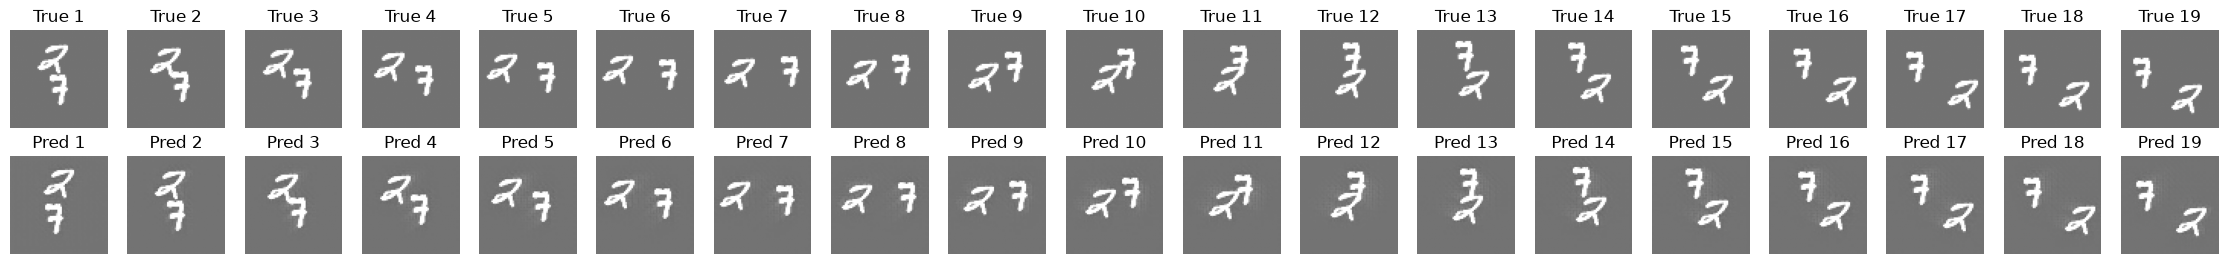

Identity check | ||delta||=0.233265  ||r_t-r_(t-1)||=11.469505  ratio=0.0203  delta_scale=1.0
Copy-last check | MSE(pred,true_t)=0.052301  MSE(pred,true_(t-1))=0.000365  gap=+0.051936  COPY
[Epoch 001/020]  r_noise=0.0026  ss_p=0.021  Next-frame MSE: 0.052301  train_δ-ratio=0.0562  val_δ-ratio=0.0203
Identity check | ||delta||=0.313146  ||r_t-r_(t-1)||=11.460271  ratio=0.0273  delta_scale=1.0
Copy-last check | MSE(pred,true_t)=0.052031  MSE(pred,true_(t-1))=0.000423  gap=+0.051609  COPY
[Epoch 002/020]  r_noise=0.0053  ss_p=0.042  Next-frame MSE: 0.052031  train_δ-ratio=0.0837  val_δ-ratio=0.0273
Identity check | ||delta||=0.376302  ||r_t-r_(t-1)||=11.451035  ratio=0.0329  delta_scale=1.0
Copy-last check | MSE(pred,true_t)=0.051803  MSE(pred,true_(t-1))=0.000479  gap=+0.051324  COPY
[Epoch 003/020]  r_noise=0.0079  ss_p=0.063  Next-frame MSE: 0.051803  train_δ-ratio=0.1055  val_δ-ratio=0.0329
Identity check | ||delta||=0.425954  ||r_t-r_(t-1)||=11.441788  ratio=0.0372  delta_scale=1.0


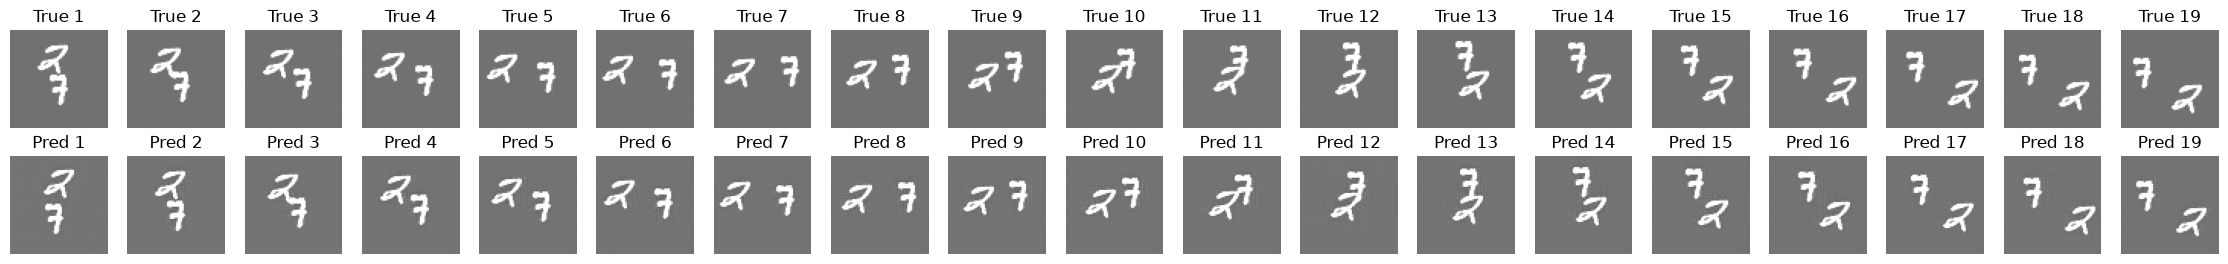

Identity check | ||delta||=0.493396  ||r_t-r_(t-1)||=11.423033  ratio=0.0432  delta_scale=1.0
Copy-last check | MSE(pred,true_t)=0.051272  MSE(pred,true_(t-1))=0.000611  gap=+0.050661  COPY
[Epoch 006/020]  r_noise=0.0158  ss_p=0.126  Next-frame MSE: 0.051272  train_δ-ratio=0.1412  val_δ-ratio=0.0432
Identity check | ||delta||=0.517266  ||r_t-r_(t-1)||=11.413669  ratio=0.0453  delta_scale=1.0
Copy-last check | MSE(pred,true_t)=0.051125  MSE(pred,true_(t-1))=0.000643  gap=+0.050481  COPY
[Epoch 007/020]  r_noise=0.0184  ss_p=0.147  Next-frame MSE: 0.051125  train_δ-ratio=0.1473  val_δ-ratio=0.0453
Identity check | ||delta||=0.539045  ||r_t-r_(t-1)||=11.404364  ratio=0.0473  delta_scale=1.0
Copy-last check | MSE(pred,true_t)=0.050982  MSE(pred,true_(t-1))=0.000673  gap=+0.050309  COPY
[Epoch 008/020]  r_noise=0.0211  ss_p=0.168  Next-frame MSE: 0.050982  train_δ-ratio=0.1537  val_δ-ratio=0.0473
Identity check | ||delta||=0.556540  ||r_t-r_(t-1)||=11.395031  ratio=0.0488  delta_scale=1.0


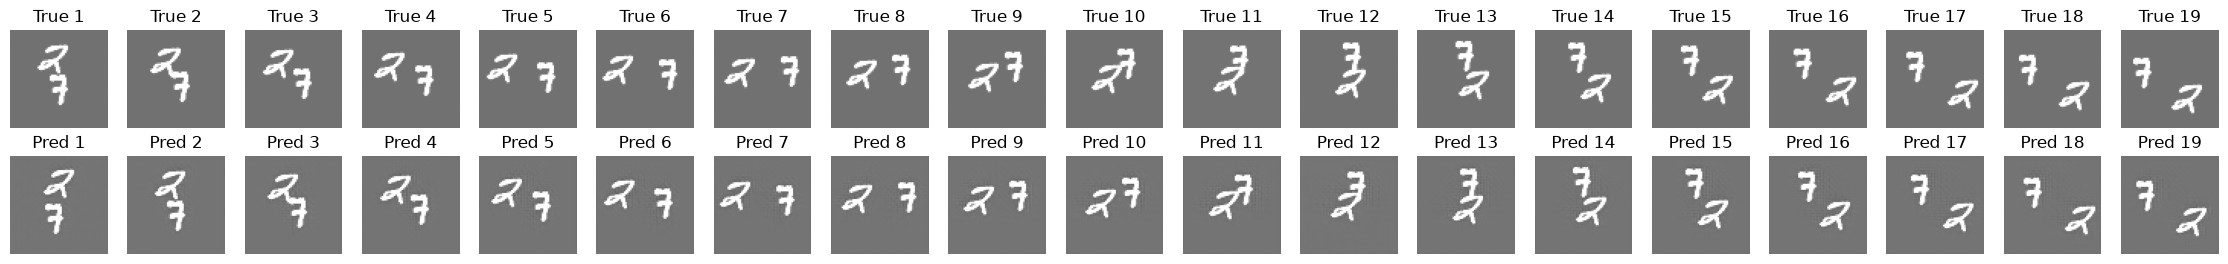

Identity check | ||delta||=0.586007  ||r_t-r_(t-1)||=11.376280  ratio=0.0515  delta_scale=1.0
Copy-last check | MSE(pred,true_t)=0.050581  MSE(pred,true_(t-1))=0.000743  gap=+0.049838  COPY
[Epoch 011/020]  r_noise=0.0289  ss_p=0.232  Next-frame MSE: 0.050581  train_δ-ratio=0.1623  val_δ-ratio=0.0515
Identity check | ||delta||=0.600648  ||r_t-r_(t-1)||=11.366900  ratio=0.0528  delta_scale=1.0
Copy-last check | MSE(pred,true_t)=0.050449  MSE(pred,true_(t-1))=0.000765  gap=+0.049684  COPY
[Epoch 012/020]  r_noise=0.0316  ss_p=0.253  Next-frame MSE: 0.050449  train_δ-ratio=0.1623  val_δ-ratio=0.0528
Identity check | ||delta||=0.619155  ||r_t-r_(t-1)||=11.357282  ratio=0.0545  delta_scale=1.0
Copy-last check | MSE(pred,true_t)=0.050314  MSE(pred,true_(t-1))=0.000789  gap=+0.049525  COPY
[Epoch 013/020]  r_noise=0.0342  ss_p=0.274  Next-frame MSE: 0.050314  train_δ-ratio=0.1543  val_δ-ratio=0.0545
Identity check | ||delta||=0.632361  ||r_t-r_(t-1)||=11.347744  ratio=0.0557  delta_scale=1.0


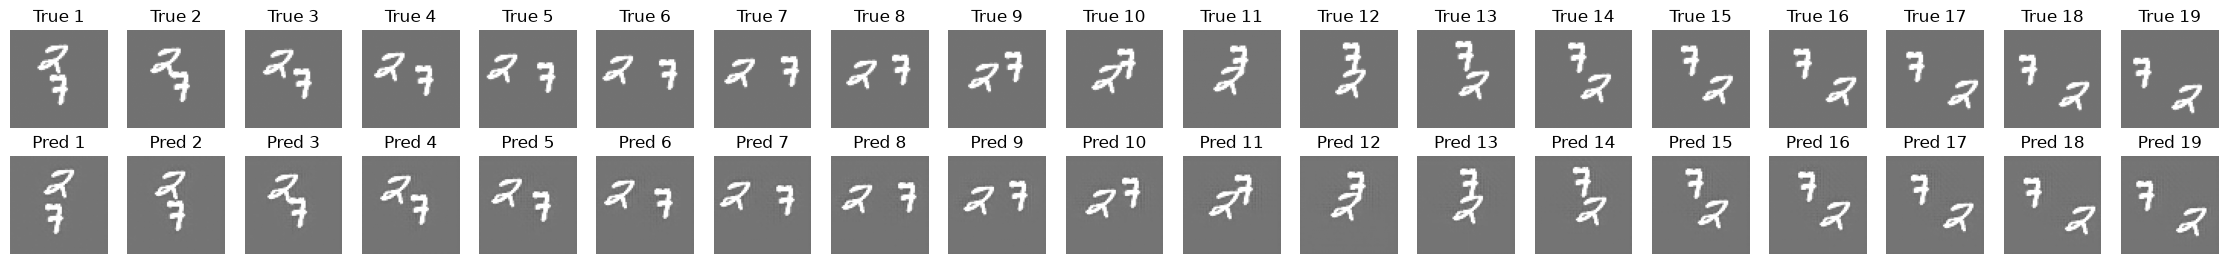

Identity check | ||delta||=0.668180  ||r_t-r_(t-1)||=11.328320  ratio=0.0590  delta_scale=1.0
Copy-last check | MSE(pred,true_t)=0.049901  MSE(pred,true_(t-1))=0.000862  gap=+0.049039  COPY
[Epoch 016/020]  r_noise=0.0421  ss_p=0.337  Next-frame MSE: 0.049901  train_δ-ratio=0.1517  val_δ-ratio=0.0590
Identity check | ||delta||=0.684548  ||r_t-r_(t-1)||=11.318682  ratio=0.0605  delta_scale=1.0
Copy-last check | MSE(pred,true_t)=0.049761  MSE(pred,true_(t-1))=0.000888  gap=+0.048873  COPY
[Epoch 017/020]  r_noise=0.0447  ss_p=0.358  Next-frame MSE: 0.049761  train_δ-ratio=0.1671  val_δ-ratio=0.0605
Identity check | ||delta||=0.703122  ||r_t-r_(t-1)||=11.309144  ratio=0.0622  delta_scale=1.0
Copy-last check | MSE(pred,true_t)=0.049617  MSE(pred,true_(t-1))=0.000915  gap=+0.048702  COPY
[Epoch 018/020]  r_noise=0.0474  ss_p=0.379  Next-frame MSE: 0.049617  train_δ-ratio=0.1697  val_δ-ratio=0.0622
Identity check | ||delta||=0.721721  ||r_t-r_(t-1)||=11.299585  ratio=0.0639  delta_scale=1.0


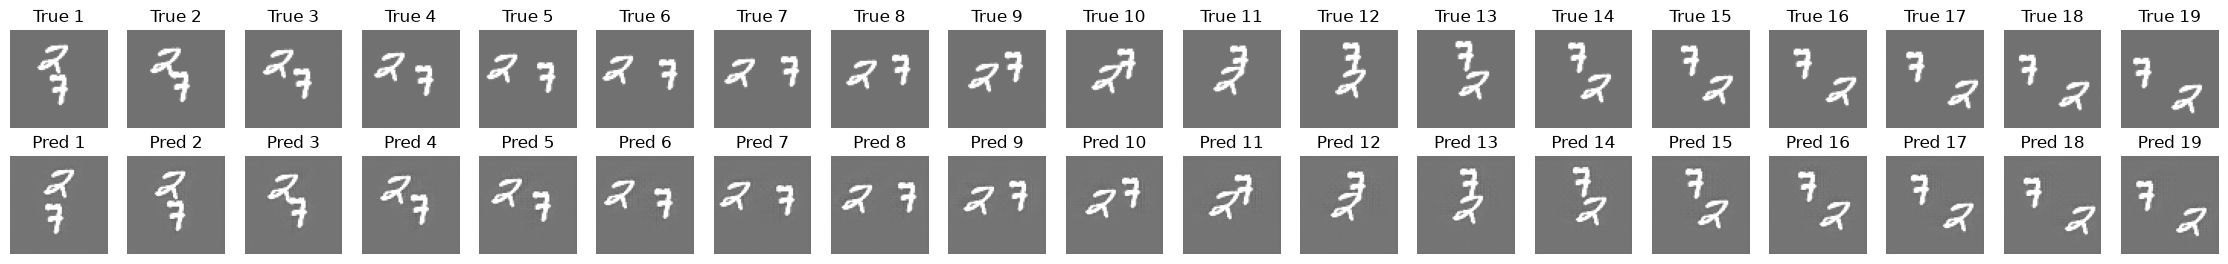


Post-train latent smoothness (learned dictionary, slowness in training only):

B. Latent smoothness [post-train warm-start (target consec cos > 0.8)]  inner=200  lr_r=0.02
Settling grounded trajectory...

   t  cos(r_t,r_t-1)  ||dr||/||r_t||      ||dr||
   1          0.5700          0.8726      7.8661
   2          0.6522          0.8137      7.7377
   3          0.6720          0.8008      7.7962
   4          0.6342          0.8617      8.2683
   5          0.6710          0.8031      7.8683
   6          0.7572          0.6888      6.9165
   7          0.6009          0.9084      8.8347
   8          0.6662          0.8079      8.0417
   9          0.6076          0.8979      8.7069
  10          0.6042          0.8954      8.5742
  11          0.6257          0.8715      8.2259
  12          0.6260          0.8551      8.2619
  13          0.6409          0.8452      8.2117
  14          0.6215          0.8712      8.4423
  15          0.6115          0.8892      8.4720
  16      

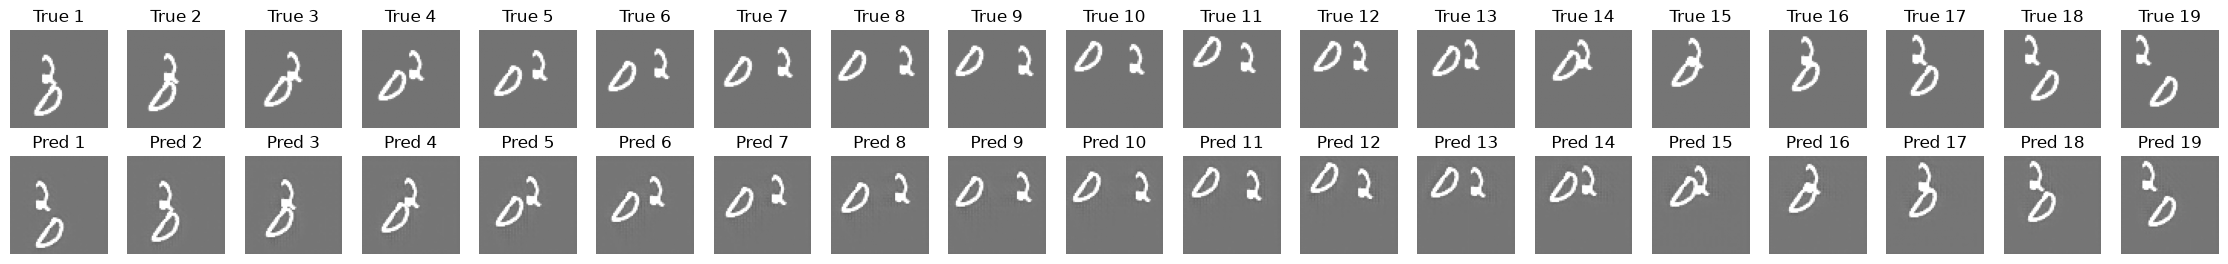

t=10 saturation | true: 0.0000 | substitute: 0.0000
Long-run  ->  MSE: 0.047883  |  Per-frame: ['0.0555', '0.0530', '0.0500', '0.0549', '0.0537', '0.0554', '0.0550', '0.0555', '0.0345', '0.0404', '0.0524', '0.0461', '0.0473', '0.0425', '0.0434', '0.0426', '0.0435', '0.0425', '0.0417']


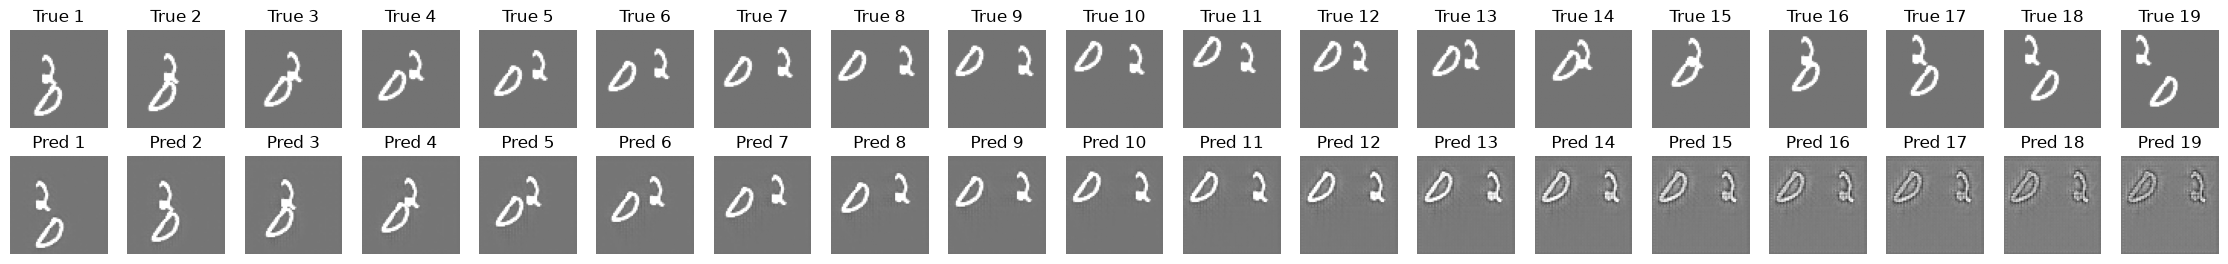

In [65]:
if __name__ == "__main__":
    main()
